# Phase 1: Disease Models Only

The vivarium 4 / vivarium_public_health 5 upgrade is being built up
incrementally. This notebook is the **Phase 1** acceptance test:

> **Goal:** load the smallest possible model spec — disease models +
> base population + a mortality observer — call `setup()`, step the
> simulation, and confirm that the disease state machines initialize
> from prevalence and that simulants transition between states.

If this notebook fails, none of the later phases (risk factors, risk
effects, healthcare/treatment, observers) can possibly work. So this
is the gate to clear before adding more components.

The model spec used here is
`src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase1.yaml`.
It loads:

- `BasePopulation` (vivarium_public_health)
- `MortalityObserver` (vivarium_public_health)
- The two disease models from `causes.yaml` parsed by
  `CausesConfigurationParser`:
    - `ischemic_stroke` (susceptible, acute, chronic)
    - `ischemic_heart_disease_and_heart_failure` (susceptible, acute MI,
      post MI, HF from IHD, acute MI + HF, HF residual)

Two patches in `plugins/__init__.py` are exercised here for the first
time:

1. **`ArtifactManager.load` draw-column stripping** — vivarium 4
   renames `draw_0` → `value` but leaves `draw_1`…`draw_249`, and the
   leftover columns get treated as categorical key columns by
   `LookupTable`. The patch drops them after load.
2. **`risk_distributions.EnsembleDistribution.get_expected_parameters`**
   shim — vph 5 expects this classmethod, but it doesn't exist on
   `risk_distributions 2.1.3`. (Not directly exercised in Phase 1
   since there are no risks, but the import happens at parser load
   time.)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vivarium import InteractiveContext

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

MODEL_SPEC = '../src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase1.yaml'


## 1. Set up the simulation

If `InteractiveContext(...)` returns without raising, the artifact
loaded cleanly, the disease models built their lookup tables, and the
initial population was sampled from prevalence.

Note that the new `vivarium 4` `get_population` API requires an explicit
list of attribute names. The `is_alive` boolean column replaces the old
`alive` string column.


In [2]:
sim = InteractiveContext(MODEL_SPEC)
print('setup OK')
print('current time:', sim.current_time)
print('configured pop size:', sim.configuration.population.population_size)


setup OK
current time: 2024-01-01 00:00:00
configured pop size: 1000


## 2. Initial population overview

The model spec initializes 1,000 simulants ages 5-125. Disease state
columns are sampled from artifact prevalence at simulation start.


In [3]:
ATTRS = [
    'age', 'sex', 'is_alive', 'cause_of_death',
    'ischemic_stroke', 'ischemic_heart_disease_and_heart_failure',
]

pop0 = sim.get_population(ATTRS)
print('shape:', pop0.shape)
print()
print('age summary:')
print(pop0['age'].describe().round(2))
print()
print('sex:')
print(pop0['sex'].value_counts())
print()
print('alive:')
print(pop0['is_alive'].value_counts())


shape: (1000, 6)

age summary:
count    1000.00
mean       42.65
std        22.14
min         5.02
25%        23.59
50%        42.23
75%        61.09
max       103.74
Name: age, dtype: float64

sex:
sex
Female    513
Male      487
Name: count, dtype: int64

alive:
is_alive
True    1000
Name: count, dtype: int64


## 3. Initial disease state distribution

The two cause models should each have most simulants in the
`susceptible_to_*` state, with a small fraction sampled into each
diseased state from the artifact prevalence.


In [4]:
print('--- ischemic_stroke ---')
print(pop0['ischemic_stroke'].value_counts())
print()
print('--- ischemic_heart_disease_and_heart_failure ---')
print(pop0['ischemic_heart_disease_and_heart_failure'].value_counts())


--- ischemic_stroke ---
ischemic_stroke
susceptible_to_ischemic_stroke    975
chronic_ischemic_stroke            25
Name: count, dtype: int64

--- ischemic_heart_disease_and_heart_failure ---
ischemic_heart_disease_and_heart_failure
susceptible_to_ischemic_heart_disease_and_heart_failure    1000
Name: count, dtype: int64


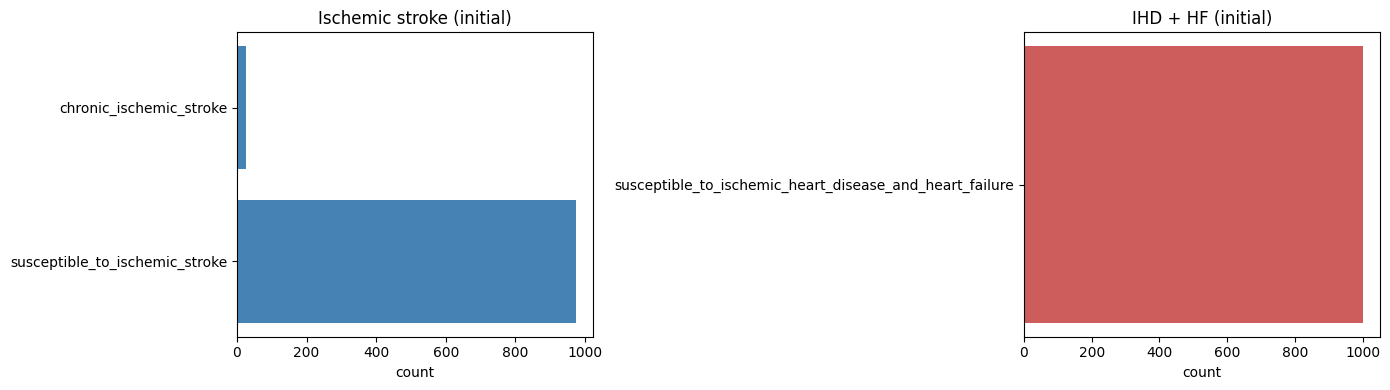

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

is_counts = pop0['ischemic_stroke'].value_counts()
axes[0].barh(is_counts.index.astype(str), is_counts.values, color='steelblue')
axes[0].set_title('Ischemic stroke (initial)')
axes[0].set_xlabel('count')

ihd_counts = pop0['ischemic_heart_disease_and_heart_failure'].value_counts()
axes[1].barh(ihd_counts.index.astype(str), ihd_counts.values, color='indianred')
axes[1].set_title('IHD + HF (initial)')
axes[1].set_xlabel('count')

plt.tight_layout()
plt.show()


## 4. Step the simulation forward

We run for one full simulated year (~13 steps of 28 days each). The
key thing this exercises is that:

- The `RateTransition` machinery built by the cause parser actually
  fires and moves simulants through state transitions.
- The mortality model retires dead simulants without crashing.
- No lookup table interpolation errors occur from leftover `draw_*`
  columns (the monkey-patch is doing its job).


In [6]:
N_STEPS = 13
for _ in range(N_STEPS):
    sim.step()
print('current time:', sim.current_time)

pop1 = sim.get_population(ATTRS)
print('alive after one year:', int(pop1['is_alive'].sum()), '/', len(pop1))


current time: 2024-12-30 00:00:00
alive after one year: 993 / 1000


In [7]:
print('--- ischemic_stroke ---')
print(pop1['ischemic_stroke'].value_counts())
print()
print('--- ischemic_heart_disease_and_heart_failure ---')
print(pop1['ischemic_heart_disease_and_heart_failure'].value_counts())


--- ischemic_stroke ---
ischemic_stroke
susceptible_to_ischemic_stroke    974
chronic_ischemic_stroke            26
Name: count, dtype: int64

--- ischemic_heart_disease_and_heart_failure ---
ischemic_heart_disease_and_heart_failure
susceptible_to_ischemic_heart_disease_and_heart_failure    988
heart_failure_from_ischemic_heart_disease                    7
heart_failure_residual                                       2
post_myocardial_infarction                                   2
acute_myocardial_infarction                                  1
Name: count, dtype: int64


## 5. State transitions across the year

Compare counts at t=0 and t=1y to verify simulants actually moved
between states (incidence + dwell-time + remission transitions all
fire).


In [8]:
def state_change_table(name: str) -> pd.DataFrame:
    a = pop0[name].value_counts()
    b = pop1[name].value_counts()
    df = pd.DataFrame({'t=0': a, 't=1y': b}).fillna(0).astype(int)
    df['delta'] = df['t=1y'] - df['t=0']
    return df.sort_values('t=0', ascending=False)

print('--- ischemic_stroke ---')
print(state_change_table('ischemic_stroke'))
print()
print('--- ischemic_heart_disease_and_heart_failure ---')
print(state_change_table('ischemic_heart_disease_and_heart_failure'))


--- ischemic_stroke ---
                                t=0  t=1y  delta
ischemic_stroke                                 
susceptible_to_ischemic_stroke  975   974     -1
chronic_ischemic_stroke          25    26      1

--- ischemic_heart_disease_and_heart_failure ---
                                                     t=0  t=1y  delta
ischemic_heart_disease_and_heart_failure                             
susceptible_to_ischemic_heart_disease_and_heart...  1000   988    -12
acute_myocardial_infarction                            0     1      1
heart_failure_from_ischemic_heart_disease              0     7      7
heart_failure_residual                                 0     2      2
post_myocardial_infarction                             0     2      2


## 6. Mortality across the year

The mortality model is firing if some simulants died from cardiac
causes (or `other_causes`) over the year.


In [9]:
print('cause_of_death after one year:')
print(pop1['cause_of_death'].value_counts())
print()
deaths = pop1[~pop1['is_alive']]
print(f'{len(deaths)} deaths total ({100 * len(deaths) / len(pop1):.1f}%)')
print()
print('mean age at death:')
print(deaths.groupby('cause_of_death')['age'].mean().round(1))


cause_of_death after one year:
cause_of_death
not_dead                                     993
other_causes                                   4
heart_failure_from_ischemic_heart_disease      2
acute_myocardial_infarction                    1
Name: count, dtype: int64

7 deaths total (0.7%)

mean age at death:
cause_of_death
acute_myocardial_infarction                  71.7
heart_failure_from_ischemic_heart_disease    86.4
other_causes                                 73.0
Name: age, dtype: float64


## 7. Verdict

If you reached this cell with no exceptions and:

- The disease state value counts above show non-trivial counts in the
  diseased states (initial prevalence sampling worked),
- The `delta` column in the state-change table shows that some
  simulants actually moved between states across the year (transitions
  fired),
- A reasonable number of deaths accumulated,

then **Phase 1 is complete** and the upgrade is ready to start adding
risk factors (Phase 2).
